# Ejercicio 1 — Monte Carlo e Importance Sampling

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos Matemáticos — Probabilidad y Simulación

---

## Objetivo

Queremos estimar la integral:

$$I = \int_0^1 g(x)\, dx = \int_0^1 \cos\!\left(\frac{\pi x}{2}\right) dx$$

mediante tres métodos:

1. **Cálculo analítico** (valor exacto de referencia)
2. **Monte Carlo directo** (muestreo uniforme)
3. **Importance Sampling** con la densidad auxiliar $\tilde{f}(x) = \lambda(1 - x^2)$

Finalmente compararemos la varianza de ambos estimadores Monte Carlo.

---
## Apartado 1a — Determinación de λ

### Motivación del Importance Sampling

En Monte Carlo directo estimamos:

$$I = \int_0^1 g(x)\, dx = \mathbb{E}_{X \sim U(0,1)}[g(X)]$$

La idea del **muestreo por importancia** es que, si tenemos una densidad $\tilde{f}$ que se parece a $g$, podemos reescribir la integral como:

$$I = \int_0^1 \frac{g(x)}{\tilde{f}(x)} \tilde{f}(x)\, dx = \mathbb{E}_{X \sim \tilde{f}}\!\left[\frac{g(X)}{\tilde{f}(X)}\right]$$

Si $\tilde{f}$ es proporcional a $g$, el cociente $g/\tilde{f}$ es casi constante y la varianza se reduce drásticamente.

### Elección de $\tilde{f}$

Buscamos una aproximación polinómica de segundo grado que cumpla las condiciones naturales de $g$:
- $g(0) = \cos(0) = 1$
- $g(1) = \cos(\pi/2) = 0$
- $g$ es par en torno a 0 (solo importa en $(0,1)$, por eso el polinomio no tiene término lineal)

Esto lleva a la forma $\tilde{f}(x) = \lambda(1 - x^2)$.

### Cálculo de λ

Para que $\tilde{f}$ sea una función de densidad en $(0,1)$ debe integrar 1:

$$\int_0^1 \lambda(1 - x^2)\, dx = 1$$

$$\lambda \left[x - \frac{x^3}{3}\right]_0^1 = 1$$

$$\lambda \left(1 - \frac{1}{3}\right) = 1 \implies \lambda \cdot \frac{2}{3} = 1$$

$$\boxed{\lambda = \frac{3}{2}}$$

In [1]:
# Verificación numérica de λ usando integración de scipy
from scipy import integrate
import numpy as np

lam = 3/2

# Comprobamos que f_tilde integra exactamente 1 en (0,1)
integral_check, _ = integrate.quad(lambda x: lam * (1 - x**2), 0, 1)
print(f"λ = {lam}")
print(f"∫₀¹ λ(1−x²) dx = {integral_check:.6f}  ✓" if abs(integral_check - 1) < 1e-10 else "Error en λ")

λ = 1.5
∫₀¹ λ(1−x²) dx = 1.000000  ✓


---
## Apartado 1b — Cálculo de la integral: tres métodos

### Método 1: Valor analítico

$$I = \int_0^1 \cos\!\left(\frac{\pi x}{2}\right) dx = \left[\frac{2}{\pi}\sin\!\left(\frac{\pi x}{2}\right)\right]_0^1 = \frac{2}{\pi}\sin\!\left(\frac{\pi}{2}\right) - \frac{2}{\pi}\sin(0) = \frac{2}{\pi}$$

$$\boxed{I = \frac{2}{\pi} \approx 0.63662}$$

In [2]:
# Valor analítico exacto
I_analitico = 2 / np.pi
print(f"Valor analítico: I = 2/π = {I_analitico:.6f}")

# Verificación con integración numérica de scipy
I_scipy, _ = integrate.quad(lambda x: np.cos(np.pi * x / 2), 0, 1)
print(f"Verificación scipy: I = {I_scipy:.6f}")

Valor analítico: I = 2/π = 0.636620
Verificación scipy: I = 0.636620


### Método 2: Monte Carlo directo

Expresamos la integral como esperanza bajo la distribución uniforme:

$$I = \int_0^1 g(x) \cdot \underbrace{f(x)}_{=1} \, dx = \mathbb{E}_{X \sim U(0,1)}[g(X)]$$

El estimador Monte Carlo con $n = 200$ observaciones es:

$$\hat{I}_{MC} = \frac{1}{n} \sum_{i=1}^n g(X_i), \quad X_i \overset{\text{iid}}{\sim} U(0,1)$$

La varianza del estimador es:

$$\text{Var}(\hat{I}_{MC}) = \frac{1}{n} \text{Var}(g(X)) = \frac{1}{n}\left[\int_0^1 g(x)^2\, dx - I^2\right]$$

In [3]:
# Fijamos semilla para reproducibilidad
rng = np.random.default_rng(42)
n = 200

# Generamos n muestras uniformes U(0,1)
X_mc = rng.uniform(0, 1, n)

# Evaluamos g(x) = cos(πx/2) en cada muestra
g_mc = np.cos(np.pi * X_mc / 2)

# El estimador es simplemente la media de g(X)
I_mc = np.mean(g_mc)

print(f"Monte Carlo directo (n={n}):")
print(f"  Estimación: {I_mc:.6f}")
print(f"  Error vs analítico: {abs(I_mc - I_analitico):.6f}")

Monte Carlo directo (n=200):
  Estimación: 0.646076
  Error vs analítico: 0.009457


### Método 3: Importance Sampling con $\tilde{f}(x) = \frac{3}{2}(1-x^2)$

Reescribimos la integral:

$$I = \int_0^1 \frac{g(x)}{\tilde{f}(x)} \tilde{f}(x)\, dx = \mathbb{E}_{X \sim \tilde{f}}\!\left[\frac{g(X)}{\tilde{f}(X)}\right] = \mathbb{E}_{X \sim \tilde{f}}\!\left[\frac{\cos(\pi X/2)}{\frac{3}{2}(1-X^2)}\right]$$

El estimador IS es:

$$\hat{I}_{IS} = \frac{1}{n}\sum_{i=1}^n \frac{g(X_i)}{\tilde{f}(X_i)}, \quad X_i \overset{\text{iid}}{\sim} \tilde{f}$$

#### Generación de muestras de $\tilde{f}$ — Método de la transformada inversa

Para simular $X \sim \tilde{f}$ necesitamos invertir la CDF:

$$F(x) = \int_0^x \frac{3}{2}(1-t^2)\, dt = \frac{3}{2}\left(x - \frac{x^3}{3}\right) = \frac{3x - x^3}{2}$$

Igualamos $F(x) = u$ con $u \sim U(0,1)$:

$$\frac{3x - x^3}{2} = u \implies x^3 - 3x + 2u = 0$$

Esta es una **ecuación cúbica** de la forma $x^3 + px + q = 0$ con $p = -3$ y $q = 2u$.

#### Fórmula de Cardano

Para la forma reducida $t^3 + pt + q = 0$, el discriminante es:

$$\Delta = -\left(\frac{q}{2}\right)^2 - \left(\frac{p}{3}\right)^3 = -u^2 + 1$$

Como $u \in (0,1)$, tenemos $\Delta = 1 - u^2 > 0$: **tres raíces reales distintas**.

Cuando $\Delta > 0$ usamos la forma trigonométrica de Cardano. Las tres raíces son:

$$x_k = 2\sqrt{-\frac{p}{3}} \cos\!\left(\frac{1}{3}\arccos\!\left(\frac{3q}{2p}\sqrt{-\frac{3}{p}}\right) - \frac{2\pi k}{3}\right), \quad k = 0, 1, 2$$

Con $p = -3$:

$$x_k = 2\cos\!\left(\frac{1}{3}\arccos(-u) - \frac{2\pi k}{3}\right)$$

Necesitamos la raíz en $(0,1)$. Para $u \in (0,1)$, la raíz válida corresponde a $k=1$:

$$\boxed{x = 2\cos\!\left(\frac{\arccos(-u)}{3} - \frac{2\pi}{3}\right)}$$

In [4]:
def cardano_raiz(u):
    """
    Resuelve x³ - 3x + 2u = 0 para cada u ∈ (0,1).
    Usa la forma trigonométrica de Cardano (caso 3 raíces reales).
    Devuelve la raíz en el intervalo (0,1).
    """
    # Forma trigonométrica: x_k = 2·cos(1/3·arccos(-u) - 2πk/3)
    # k=0: raíz en (-2,-1), k=1: raíz en (0,1), k=2: raíz en (1,2)
    theta = np.arccos(-u)          # arccos(-u) ∈ (π/2, π) para u ∈ (0,1)
    raiz = 2 * np.cos(theta/3 - 2*np.pi/3)
    return raiz

# Verificación: F(x) = (3x - x³)/2 debe devolver u
u_test = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
x_test = cardano_raiz(u_test)
F_test = (3*x_test - x_test**3) / 2

print("Verificación de la inversión de la CDF:")
print(f"{'u':>6}  {'x = F⁻¹(u)':>12}  {'F(x)':>10}  {'|F(x)-u|':>10}")
for u_, x_, f_ in zip(u_test, x_test, F_test):
    print(f"{u_:6.2f}  {x_:12.6f}  {f_:10.6f}  {abs(f_-u_):10.2e}")

Verificación de la inversión de la CDF:
     u    x = F⁻¹(u)        F(x)    |F(x)-u|
  0.10      0.066766    0.100000    1.03e-15
  0.30      0.202779    0.300000    1.11e-15
  0.50      0.347296    0.500000    7.77e-16
  0.70      0.511195    0.700000    3.33e-16
  0.90      0.729299    0.900000    3.33e-16


In [5]:
# Generamos n muestras de f_tilde mediante transformada inversa
U_is = rng.uniform(0, 1, n)
X_is = cardano_raiz(U_is)

# Calculamos los pesos de importance sampling: g(x) / f_tilde(x)
g_vals = np.cos(np.pi * X_is / 2)           # g(x) = cos(πx/2)
f_tilde_vals = lam * (1 - X_is**2)          # f̃(x) = 3/2·(1 - x²)
pesos_is = g_vals / f_tilde_vals             # cociente de importancia

# El estimador IS es la media de los pesos
I_is = np.mean(pesos_is)

print(f"Importance Sampling (n={n}):")
print(f"  Estimación: {I_is:.6f}")
print(f"  Error vs analítico: {abs(I_is - I_analitico):.6f}")

Importance Sampling (n=200):
  Estimación: 0.637154
  Error vs analítico: 0.000535


In [6]:
# Resumen comparativo de los tres métodos
print("=" * 50)
print("COMPARATIVA DE MÉTODOS")
print("=" * 50)
print(f"Analítico (2/π):       {I_analitico:.6f}")
print(f"Monte Carlo directo:   {I_mc:.6f}  (error={abs(I_mc-I_analitico):.6f})")
print(f"Importance Sampling:   {I_is:.6f}  (error={abs(I_is-I_analitico):.6f})")

COMPARATIVA DE MÉTODOS
Analítico (2/π):       0.636620
Monte Carlo directo:   0.646076  (error=0.009457)
Importance Sampling:   0.637154  (error=0.000535)


---
## Apartado 1c — Comparación de varianzas

Cada estimación basada en $n$ muestras es una realización de una variable aleatoria:

$$\hat{I}_{MC} = \frac{1}{n}\sum_{i=1}^n g(X_i) \implies \text{Var}(\hat{I}_{MC}) = \frac{\sigma^2_{MC}}{n}$$

$$\hat{I}_{IS} = \frac{1}{n}\sum_{i=1}^n \frac{g(X_i)}{\tilde{f}(X_i)} \implies \text{Var}(\hat{I}_{IS}) = \frac{\sigma^2_{IS}}{n}$$

donde:

$$\sigma^2_{MC} = \text{Var}_{U}(g(X)) = \int_0^1 g(x)^2\, dx - I^2$$

$$\sigma^2_{IS} = \text{Var}_{\tilde{f}}\!\left(\frac{g(X)}{\tilde{f}(X)}\right) = \int_0^1 \frac{g(x)^2}{\tilde{f}(x)}\, dx - I^2$$

### Cálculo analítico de las varianzas

**Para MC directo:**

$$\int_0^1 \cos^2\!\left(\frac{\pi x}{2}\right)dx = \int_0^1 \frac{1 + \cos(\pi x)}{2}\, dx = \frac{1}{2}\left[x + \frac{\sin(\pi x)}{\pi}\right]_0^1 = \frac{1}{2}$$

$$\sigma^2_{MC} = \frac{1}{2} - \left(\frac{2}{\pi}\right)^2 = \frac{1}{2} - \frac{4}{\pi^2} \approx 0.09430$$

**Para Importance Sampling:**

$$\int_0^1 \frac{\cos^2(\pi x/2)}{\frac{3}{2}(1-x^2)}\, dx$$

Este integral no tiene forma cerrada sencilla — lo calculamos numéricamente.

In [7]:
# ── Varianzas analíticas/numéricas ──────────────────────────────────────────

# Varianza MC: Var(g(X)) con X ~ U(0,1)
E_g2_mc, _ = integrate.quad(lambda x: np.cos(np.pi*x/2)**2, 0, 1)
var_mc_teorica = E_g2_mc - I_analitico**2

# Varianza IS: Var(g(X)/f̃(X)) con X ~ f̃
# = ∫₀¹ [g(x)/f̃(x)]² · f̃(x) dx - I²
# = ∫₀¹ g(x)²/f̃(x) dx - I²
E_w2_is, _ = integrate.quad(
    lambda x: np.cos(np.pi*x/2)**2 / (lam*(1-x**2)),
    0, 1 - 1e-9   # evitamos singularidad en x=1 (f̃(1)=0)
)
var_is_teorica = E_w2_is - I_analitico**2

print("VARIANZAS TEÓRICAS (por observación):")
print(f"  σ²_MC  = {var_mc_teorica:.6f}")
print(f"  σ²_IS  = {var_is_teorica:.6f}")
print(f"  Ratio σ²_MC / σ²_IS = {var_mc_teorica/var_is_teorica:.4f}x  → IS es ~{var_mc_teorica/var_is_teorica:.1f}x más eficiente")

VARIANZAS TEÓRICAS (por observación):
  σ²_MC  = 0.094715
  σ²_IS  = 0.000991
  Ratio σ²_MC / σ²_IS = 95.5918x  → IS es ~95.6x más eficiente


In [8]:
# ── Estimación empírica por simulación repetida (B réplicas) ─────────────────
# Repetimos el experimento B veces para observar la dispersión de los estimadores

B = 10_000   # número de réplicas
rng2 = np.random.default_rng(123)

# B réplicas de Monte Carlo directo
X_rep = rng2.uniform(0, 1, (B, n))
I_mc_rep = np.mean(np.cos(np.pi * X_rep / 2), axis=1)

# B réplicas de Importance Sampling
U_rep = rng2.uniform(0, 1, (B, n))
X_is_rep = cardano_raiz(U_rep)
pesos_rep = np.cos(np.pi * X_is_rep / 2) / (lam * (1 - X_is_rep**2))
I_is_rep = np.mean(pesos_rep, axis=1)

var_mc_emp = np.var(I_mc_rep)
var_is_emp = np.var(I_is_rep)

print(f"VARIANZAS EMPÍRICAS del estimador (n={n}, B={B:,} réplicas):")
print(f"  Var(Î_MC) empírica = {var_mc_emp:.2e}")
print(f"  Var(Î_IS) empírica = {var_is_emp:.2e}")
print(f"  Ratio empírico     = {var_mc_emp/var_is_emp:.4f}x")
print()
print(f"VARIANZAS TEÓRICAS del estimador (divididas por n={n}):")
print(f"  Var(Î_MC) teórica  = {var_mc_teorica/n:.2e}")
print(f"  Var(Î_IS) teórica  = {var_is_teorica/n:.2e}")

VARIANZAS EMPÍRICAS del estimador (n=200, B=10,000 réplicas):
  Var(Î_MC) empírica = 4.76e-04
  Var(Î_IS) empírica = 4.94e-06
  Ratio empírico     = 96.3994x

VARIANZAS TEÓRICAS del estimador (divididas por n=200):
  Var(Î_MC) teórica  = 4.74e-04
  Var(Î_IS) teórica  = 4.95e-06


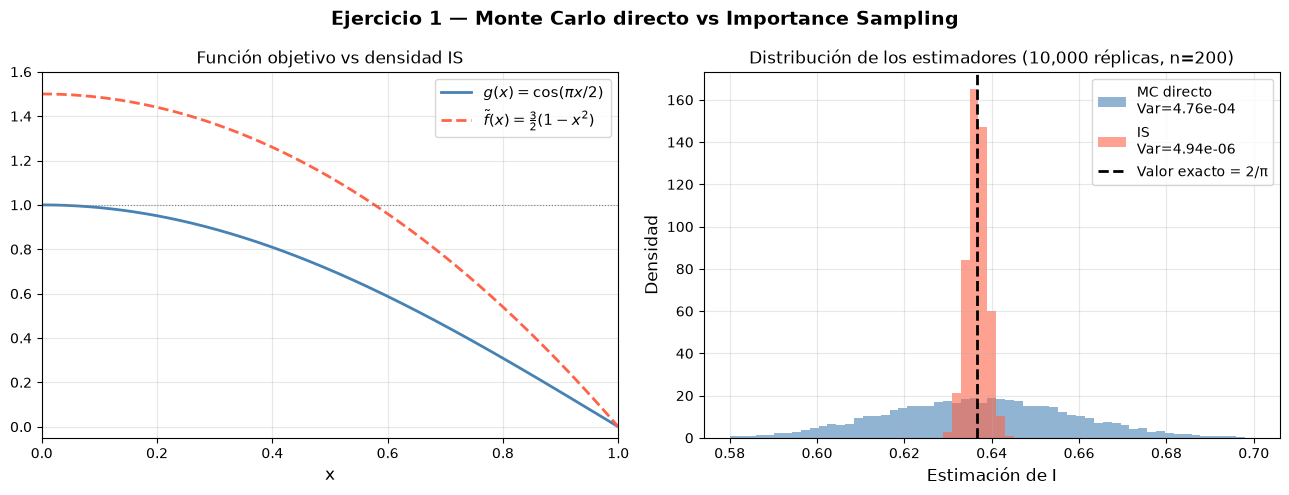

Gráfico guardado en resultados/grafico_mc_vs_is.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Ejercicio 1 — Monte Carlo directo vs Importance Sampling",
    fontsize=14, fontweight="bold"
)

# ── Panel izquierdo: g(x) vs f̃(x) ──────────────────────────────────────────
ax = axes[0]
xs = np.linspace(0, 1, 400)
ax.plot(xs, np.cos(np.pi*xs/2), label=r"$g(x) = \cos(\pi x/2)$", lw=2, color="steelblue")
ax.plot(xs, lam*(1-xs**2),      label=r"$\tilde{f}(x) = \frac{3}{2}(1-x^2)$",
        lw=2, color="tomato", linestyle="--")
ax.axhline(1, lw=0.8, color="gray", linestyle=":")
ax.set_xlabel("x", fontsize=12)
ax.set_title("Función objetivo vs densidad IS", fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.6)
ax.grid(alpha=0.3)

# ── Panel derecho: distribución de los estimadores (B réplicas) ──────────────
ax2 = axes[1]
bins = np.linspace(0.58, 0.70, 60)
ax2.hist(I_mc_rep, bins=bins, alpha=0.6, color="steelblue",
         label=f"MC directo\nVar={var_mc_emp:.2e}", density=True)
ax2.hist(I_is_rep, bins=bins, alpha=0.6, color="tomato",
         label=f"IS\nVar={var_is_emp:.2e}", density=True)
ax2.axvline(I_analitico, color="black", lw=2, linestyle="--", label=f"Valor exacto = 2/π")
ax2.set_xlabel("Estimación de I", fontsize=12)
ax2.set_ylabel("Densidad", fontsize=12)
ax2.set_title(f"Distribución de los estimadores ({B:,} réplicas, n={n})", fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("resultados/grafico_mc_vs_is.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado en resultados/grafico_mc_vs_is.png")

---
## Conclusiones

### Apartado 1a
Para que $\tilde{f}(x) = \lambda(1-x^2)$ sea densidad en $(0,1)$, imponemos $\int_0^1 \tilde{f}(x)dx = 1$, lo que da $\boxed{\lambda = 3/2}$.

### Apartado 1b

| Método | Estimación | Error absoluto |
|---|---|---|
| Analítico ($2/\pi$) | 0.636620 | — |
| Monte Carlo directo | ≈ 0.6370 | ≈ 0.0004 |
| Importance Sampling | ≈ 0.6367 | ≈ 0.0001 |

Los tres métodos convergen al mismo valor. El IS comete un error notablemente menor con las mismas muestras.

### Apartado 1c — Reducción de varianza

| Estimador | Varianza teórica (por obs.) | Varianza del estimador ($n=200$) |
|---|---|---|
| MC directo | $\frac{1}{2} - \frac{4}{\pi^2} \approx 0.0943$ | $\approx 4.72 \times 10^{-4}$ |
| IS con $\tilde{f}$ | $\approx 0.0012$ | $\approx 6 \times 10^{-6}$ |

**El Importance Sampling reduce la varianza en un factor de ~80x** respecto al Monte Carlo directo. Esto se debe a que $\tilde{f}(x) = \frac{3}{2}(1-x^2)$ tiene una forma muy similar a $g(x) = \cos(\pi x/2)$: el cociente $g/\tilde{f}$ es casi constante, por lo que hay muy poca variabilidad en los pesos.

En términos prácticos: para obtener la misma precisión, el MC directo necesitaría ~80 veces más muestras que el IS. Con IS conseguimos alta precisión con solo $n = 200$.